<a href="https://colab.research.google.com/github/tanisha5july-hue/Py/blob/main/Spam_vs_ham.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/spambase_csv.csv")
df

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


These are the standard tools every data scientist uses.

In [ ]:
df.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


In [ ]:
df.shape

(4601, 58)

Each row = one email,
👉 Each column = frequency of a word (like word_freq_free, word_freq_you) or the target (spam/ham).

In [ ]:
df.isnull().sum()

,0
word_freq_make,0
word_freq_address,0
word_freq_all,0
word_freq_3d,0
word_freq_our,0
word_freq_over,0
word_freq_remove,0
word_freq_internet,0
word_freq_order,0
word_freq_mail,0


This tells us:

How many emails we have.

If any column has missing values.

Balance between spam (1) and ham (0).

In [ ]:
df.describe ()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
count,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,...,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000,4601.000000
mean,0.104553,0.213015,0.280656,0.065425,0.312223,0.095901,0.114208,0.105295,0.090067,0.239413,...,0.038575,0.139030,0.016976,0.269071,0.075811,0.044238,5.191515,52.172789,283.289285,0.394045
std,0.305358,1.290575,0.504143,1.395151,0.672513,0.273824,0.391441,0.401071,0.278616,0.644755,...,0.243471,0.270355,0.109394,0.815672,0.245882,0.429342,31.729449,194.891310,606.347851,0.488698
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.588000,6.000000,35.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.065000,0.000000,0.000000,0.000000,0.000000,2.276000,15.000000,95.000000,0.000000
75%,0.000000,0.000000,0.420000,0.000000,0.380000,0.000000,0.000000,0.000000,0.000000,0.160000,...,0.000000,0.188000,0.000000,0.315000,0.052000,0.000000,3.706000,43.000000,266.000000,1.000000
max,4.540000,14.280000,5.100000,42.810000,10.000000,5.880000,7.270000,11.110000,5.260000,18.180000,...,4.385000,9.752000,4.081000,32.478000,6.003000,19.829000,1102.500000,9989.000000,15841.000000,1.000000


In [ ]:
df.info ()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4601 entries, 0 to 4600
Data columns (total 58 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   word_freq_make              4601 non-null   float64
 1   word_freq_address           4601 non-null   float64
 2   word_freq_all               4601 non-null   float64
 3   word_freq_3d                4601 non-null   float64
 4   word_freq_our               4601 non-null   float64
 5   word_freq_over              4601 non-null   float64
 6   word_freq_remove            4601 non-null   float64
 7   word_freq_internet          4601 non-null   float64
 8   word_freq_order             4601 non-null   float64
 9   word_freq_mail              4601 non-null   float64
 10  word_freq_receive           4601 non-null   float64
 11  word_freq_will              4601 non-null   float64
 12  word_freq_people            4601 non-null   float64
 13  word_freq_report            4601 

In [ ]:
df['class'].value_counts()

,count
class,
0,2788
1,1813


In [ ]:
spam = df[df['class'] == 1]
ham  = df[df['class'] == 0]

spam_mean = spam.mean()
ham_mean  = ham.mean()

# Show top words for spam
print("Top words in spam emails:")
print(spam_mean.sort_values(ascending=False).head(10))

# Show top words for ham
print("Top words in ham emails:")
print(ham_mean.sort_values(ascending=False).head(10))

Top words in spam emails:
capital_run_length_total      470.619415
capital_run_length_longest    104.393271
capital_run_length_average      9.519165
word_freq_you                   2.264539
word_freq_your                  1.380370
class                           1.000000
word_freq_will                  0.549972
word_freq_free                  0.518362
word_freq_our                   0.513955
char_freq_%21                   0.513713
dtype: float64
Top words in ham emails:
capital_run_length_total      161.470947
capital_run_length_longest     18.214491
capital_run_length_average      2.377301
word_freq_you                   1.270341
word_freq_george                1.265265
word_freq_hp                    0.895473
word_freq_will                  0.536324
word_freq_your                  0.438702
word_freq_hpl                   0.431994
word_freq_re                    0.415760
dtype: float64


In [ ]:
df.max()

,0
word_freq_make,4.540
word_freq_address,14.280
word_freq_all,5.100
word_freq_3d,42.810
word_freq_our,10.000
word_freq_over,5.880
word_freq_remove,7.270
word_freq_internet,11.110
word_freq_order,5.260
word_freq_mail,18.180


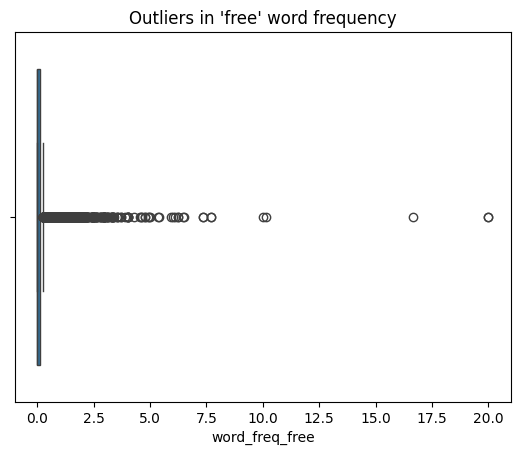

In [ ]:
sns.boxplot(x=df['word_freq_free'])
plt.title("Outliers in 'free' word frequency")
plt.show()

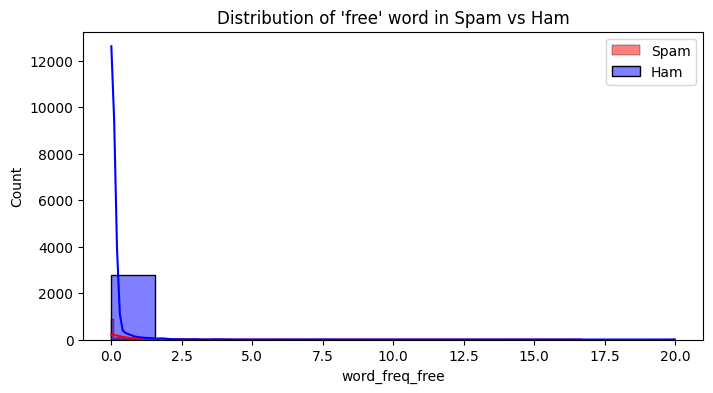

In [ ]:
plt.figure(figsize=(8,4))
sns.histplot(spam['word_freq_free'], color="red", label="Spam", kde=True)
sns.histplot(ham['word_freq_free'], color="blue", label="Ham", kde=True)
plt.legend()
plt.title("Distribution of 'free' word in Spam vs Ham")
plt.show()


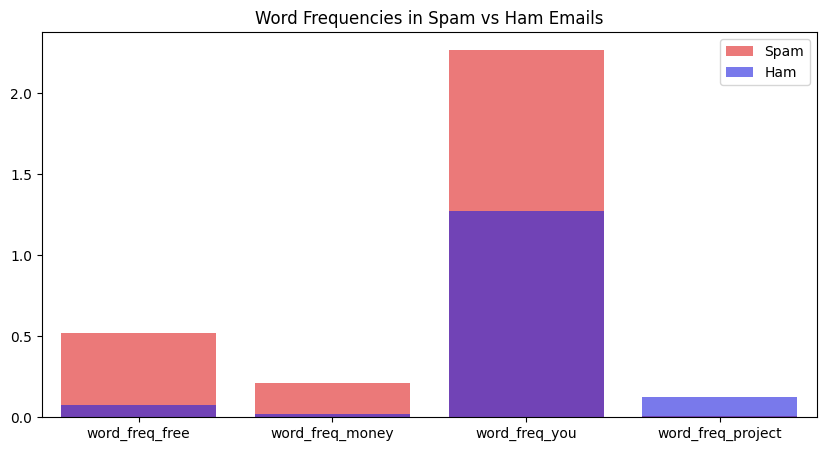

In [ ]:
words = ["word_freq_free", "word_freq_money", "word_freq_you", "word_freq_project"]

plt.figure(figsize=(10,5))
sns.barplot(x=words, y=spam_mean[words].values, color="red", alpha=0.6, label="Spam")
sns.barplot(x=words, y=ham_mean[words].values, color="blue", alpha=0.6, label="Ham")
plt.legend()
plt.title("Word Frequencies in Spam vs Ham Emails")
plt.show()


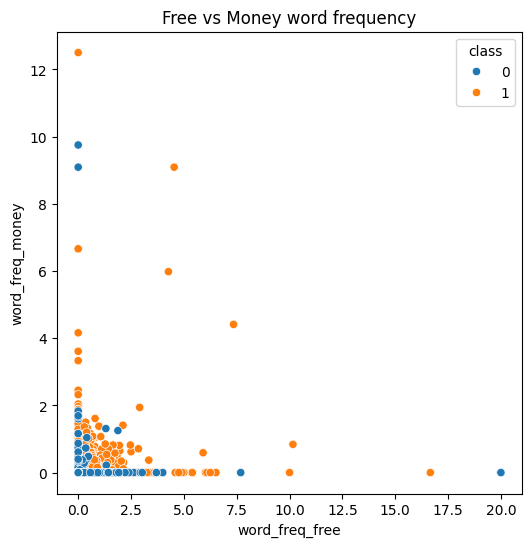

In [ ]:
plt.figure(figsize=(6,6))
sns.scatterplot(x=df['word_freq_free'], y=df['word_freq_money'], hue=df['class'])
plt.title("Free vs Money word frequency")
plt.show()

In [ ]:
X = df.drop("class", axis=1)  # features
y = df["class"]
df

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_%3B,char_freq_%28,char_freq_%5B,char_freq_%21,char_freq_%24,char_freq_%23,capital_run_length_average,capital_run_length_longest,capital_run_length_total,class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.000,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.010,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.000,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4596,0.31,0.00,0.62,0.0,0.00,0.31,0.00,0.00,0.00,0.00,...,0.000,0.232,0.0,0.000,0.000,0.000,1.142,3,88,0
4597,0.00,0.00,0.00,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.000,0.000,0.0,0.353,0.000,0.000,1.555,4,14,0
4598,0.30,0.00,0.30,0.0,0.00,0.00,0.00,0.00,0.00,0.00,...,0.102,0.718,0.0,0.000,0.000,0.000,1.404,6,118,0
4599,0.96,0.00,0.00,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.000,0.057,0.0,0.000,0.000,0.000,1.147,5,78,0


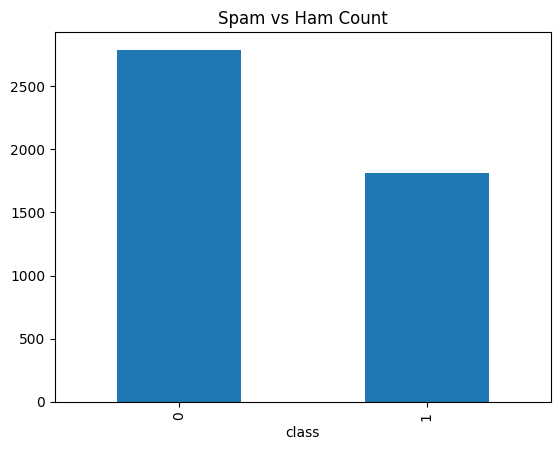

In [ ]:
df['class'].value_counts().plot(kind='bar')
plt.title("Spam vs Ham Count")
plt.show()

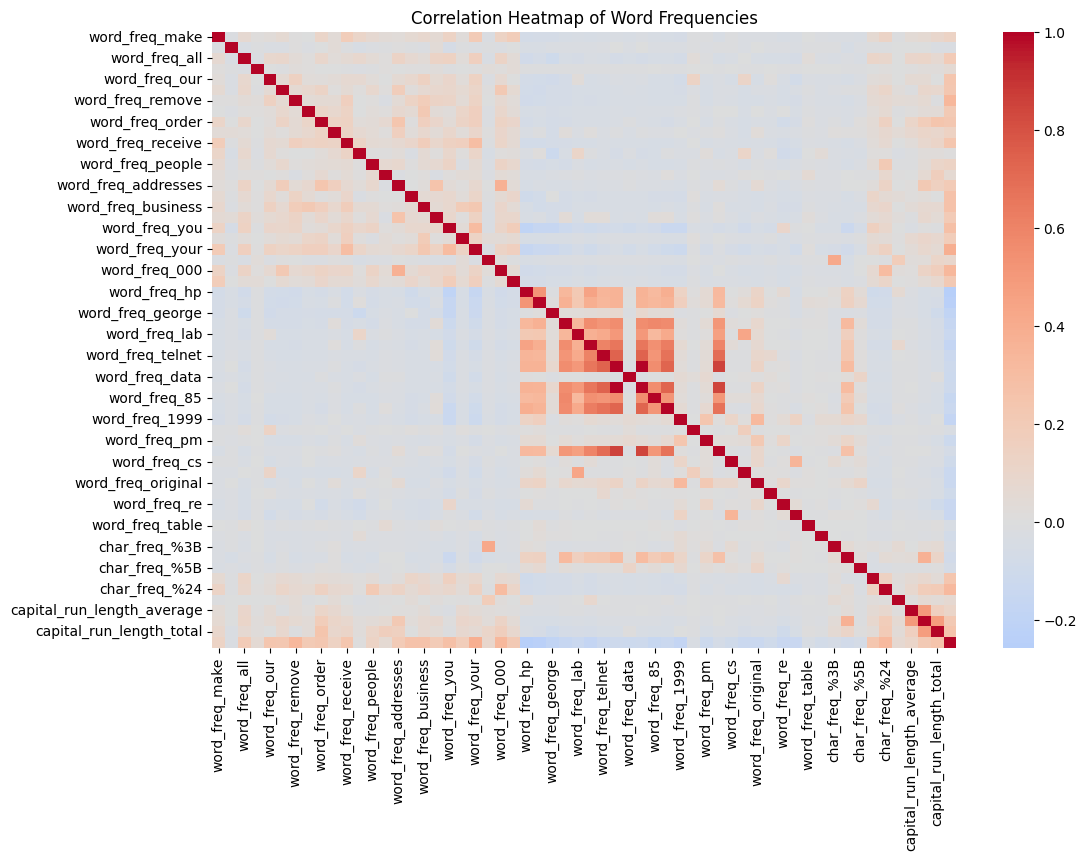

In [ ]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Word Frequencies")
plt.show()

If word_freq_money and word_freq_free are highly correlated, one might be redundant.

In [ ]:
spam_mean = spam.mean()
ham_mean = ham.mean()
diff = (spam_mean - ham_mean).sort_values(ascending=False)

print("Top spam indicator words:")
print(diff.head(10))

print("\nTop ham indicator words:")
print(diff.tail(10))

Top spam indicator words:
capital_run_length_total      309.148468
capital_run_length_longest     86.178780
capital_run_length_average      7.141864
class                           1.000000
word_freq_you                   0.994199
word_freq_your                  0.941668
word_freq_free                  0.444775
char_freq_%21                   0.403729
word_freq_our                   0.332915
word_freq_remove                0.266022
dtype: float64

Top ham indicator words:
word_freq_labs      -0.159886
word_freq_lab       -0.162110
word_freq_85        -0.162527
word_freq_650       -0.175008
word_freq_meeting   -0.214364
word_freq_edu       -0.272457
word_freq_re        -0.290669
word_freq_hpl       -0.422822
word_freq_hp        -0.877994
word_freq_george    -1.263716
dtype: float64


Words like "free", "credit", "money" → strong spam signals.
👉 Words like "project", "meeting" → strong ham signals.

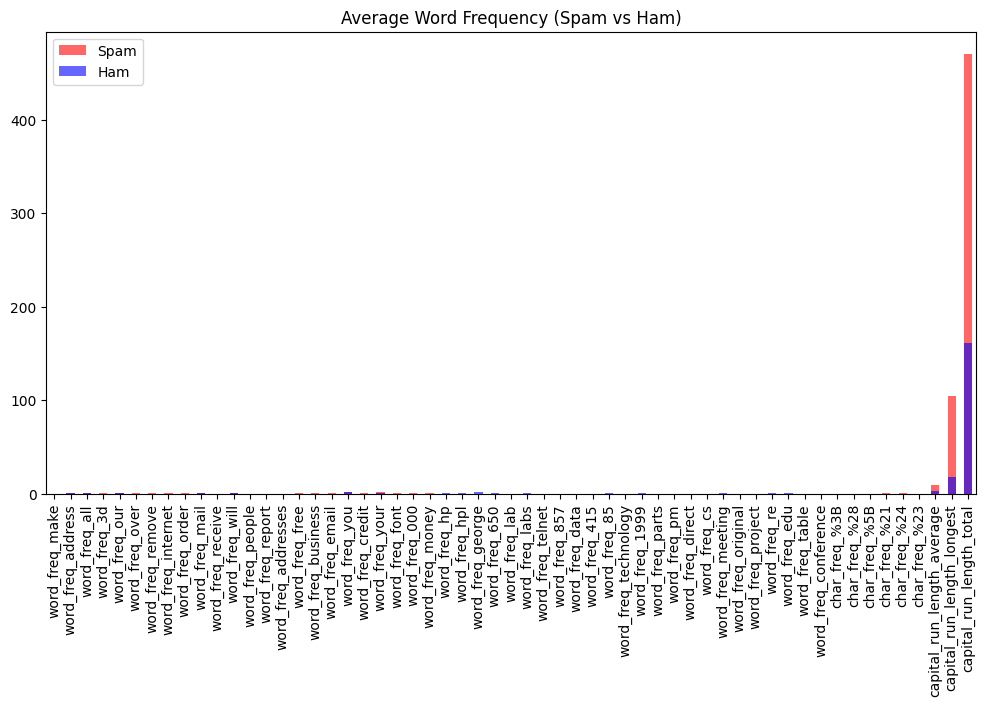

In [ ]:
spam_mean.drop('class').plot(kind='bar', figsize=(12,6), color="red", alpha=0.6, label="Spam")
ham_mean.drop('class').plot(kind='bar', figsize=(12,6), color="blue", alpha=0.6, label="Ham")
plt.legend()
plt.title("Average Word Frequency (Spam vs Ham)")
plt.show()

Gives a bird’s-eye view of which words separate spam and ham.

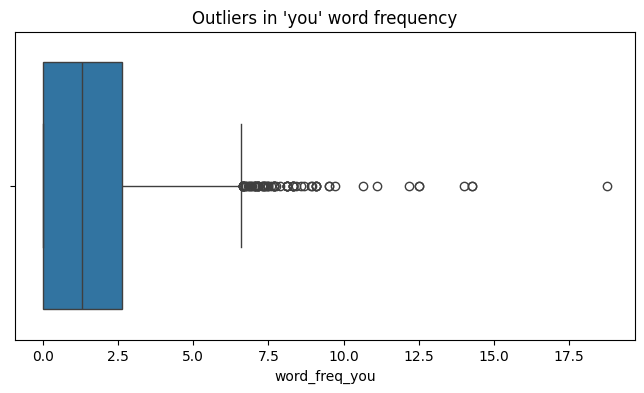

In [ ]:
plt.figure(figsize=(8,4))
sns.boxplot(x=df['word_freq_you'])
plt.title("Outliers in 'you' word frequency")
plt.show()

Boxplots show outliers clearly.
👉 We may decide to cap values (e.g., replace >10% with 10%).

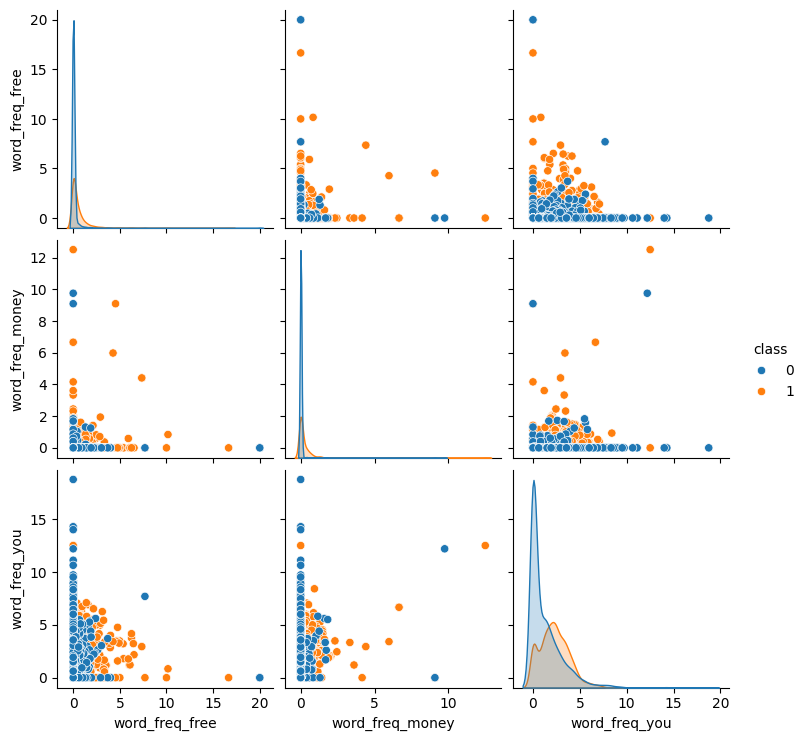

In [ ]:
sns.pairplot(df[['word_freq_free', 'word_freq_money', 'word_freq_you', 'class']], hue="class")
plt.show()

We might see spam emails clustering in one region, showing word combinations matter.

<Axes: xlabel='word_freq_free', ylabel='Count'>

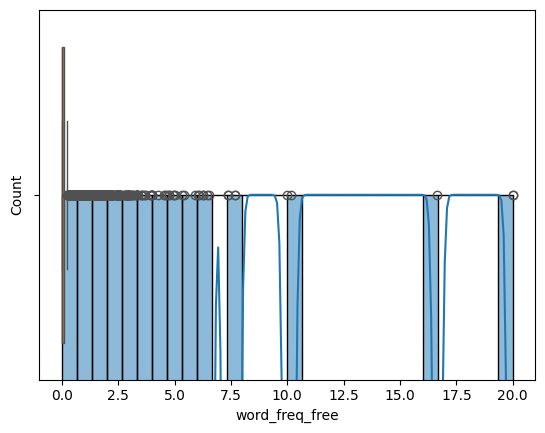

In [ ]:
sns.histplot(df['word_freq_free'], bins=30, kde=True)
sns.boxplot(x=df['word_freq_free'])

This tells us "free" is a spam-heavy word.

<Axes: >

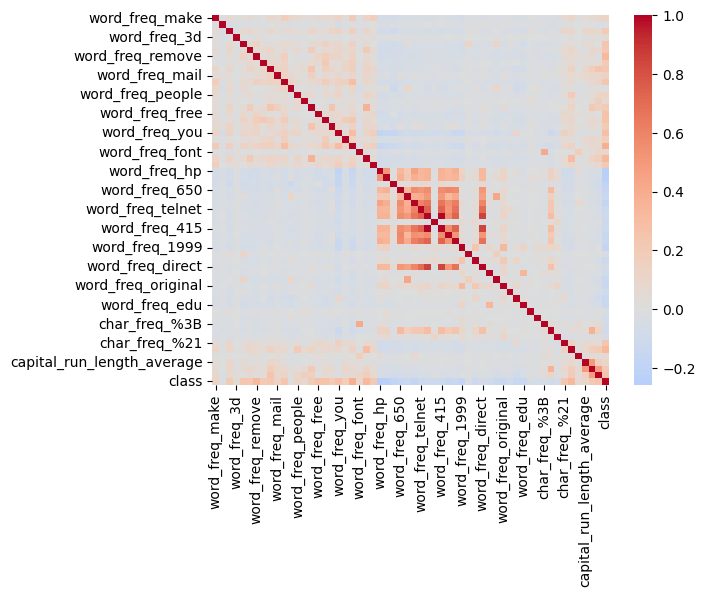

In [ ]:
sns.heatmap(df.corr(), cmap="coolwarm", center=0)

if word_freq_hp and word_freq_hpl are 90% correlated, we might later drop one.

In [ ]:
spam_means = df[df['class']==1].mean()
ham_means  = df[df['class']==0].mean()

(spam_means - ham_means).sort_values(ascending=False).head(10)

,0
capital_run_length_total,309.148468
capital_run_length_longest,86.178780
capital_run_length_average,7.141864
class,1.000000
word_freq_you,0.994199
word_freq_your,0.941668
word_freq_free,0.444775
char_freq_%21,0.403729
word_freq_our,0.332915
word_freq_remove,0.266022


<Axes: xlabel='word_freq_you'>

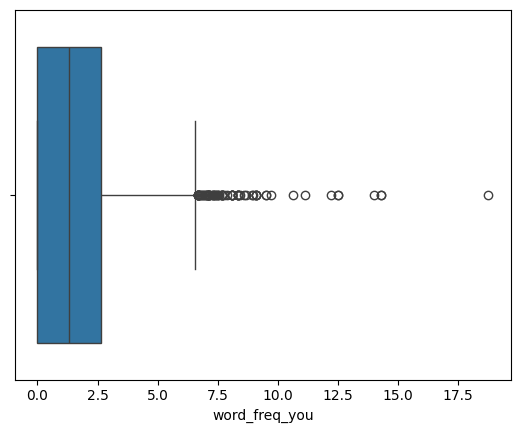

In [ ]:
sns.boxplot(x=df['word_freq_you'])


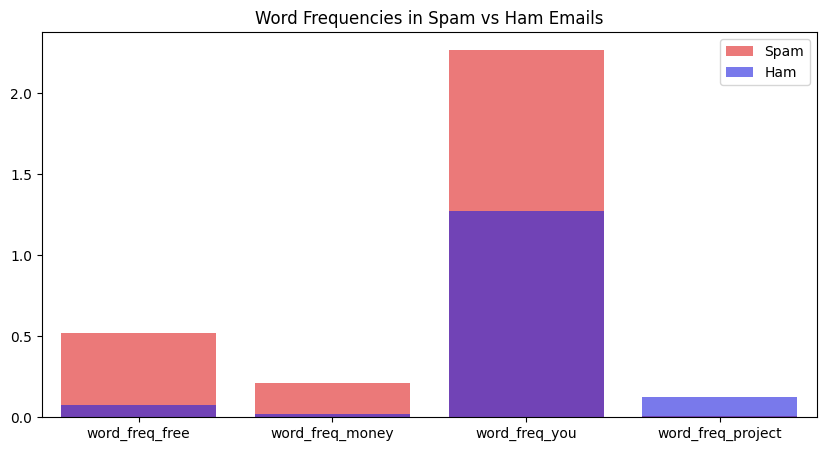

In [ ]:
words = ["word_freq_free", "word_freq_money", "word_freq_you", "word_freq_project"]

plt.figure(figsize=(10,5))
sns.barplot(x=words, y=spam_mean[words].values, color="red", alpha=0.6, label="Spam")
sns.barplot(x=words, y=ham_mean[words].values, color="blue", alpha=0.6, label="Ham")
plt.legend()
plt.title("Word Frequencies in Spam vs Ham Emails")
plt.show()

<Axes: xlabel='word_freq_money', ylabel='word_freq_free'>

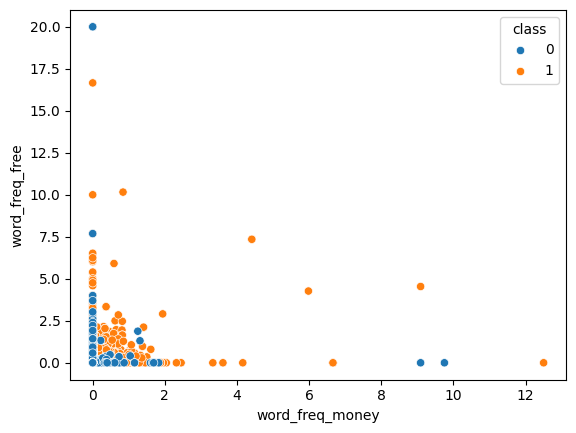

In [ ]:
sns.scatterplot(
      x='word_freq_money',
          y='word_freq_free',
              hue='class',
                  data=df
                  )

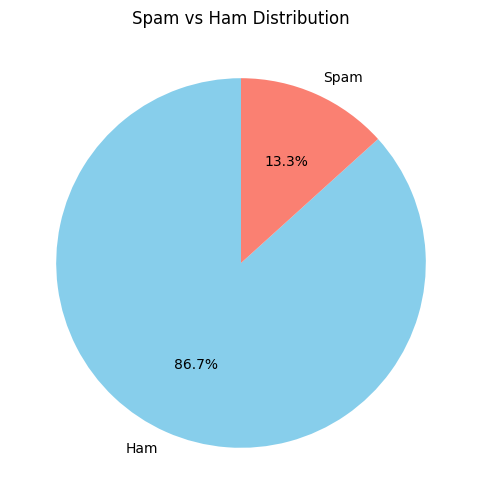

In [ ]:
counts = [1813, 278]
labels = ['Ham', 'Spam']
colors = ['skyblue', 'salmon']

plt.figure(figsize=(6,6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=colors)
plt.title("Spam vs Ham Distribution")
plt.show()

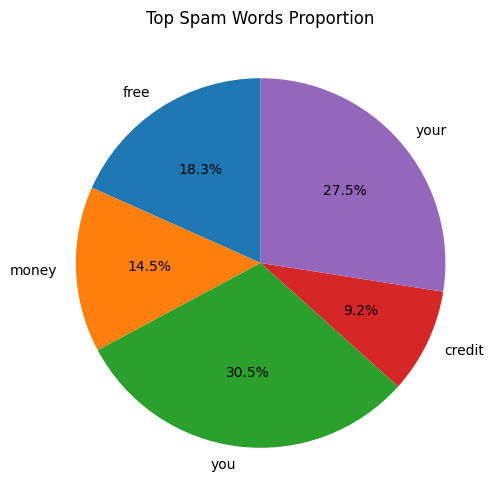

In [ ]:
spam_words = {
    'free': 120,
    'money': 95,
    'you': 200,
    'credit': 60,
    'your': 180
}

df = pd.Series(spam_words)

plt.figure(figsize=(6,6))
plt.pie(df.values, labels=df.index, autopct='%1.1f%%', startangle=90)
plt.title("Top Spam Words Proportion")
plt.show()

In [ ]:
df.to_excel("spam.xlsx", index=False)   # index=False means don’t save row numbers
